In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df_clinico = pd.read_csv('csv/internamentos_respiratorios_palmas.csv')
df_climatico = pd.read_csv('csv/particulas_ar_palmas.csv')


df_clinico['DT_INTER'] = pd.to_datetime(df_clinico["DT_INTER"])
df_climatico['time'] = pd.to_datetime(df_climatico["time"]).dt.normalize()

df_climatico_diario = df_climatico.groupby('time')['pm2p5'].mean().reset_index()
df_clinico_diario = df_clinico.groupby('DT_INTER').size().reset_index(name='total_internamentos')

df_final = pd.merge(
    df_clinico_diario,
    df_climatico_diario,
    left_on='DT_INTER',
    right_on='time',
    how='inner'
)


In [10]:
df_final

,DT_INTER,total_internamentos,time,pm2p5
0,2007-09-05,1,2007-09-05,1.188463e-08
1,2007-09-07,1,2007-09-07,1.335781e-08
2,2007-09-09,1,2007-09-09,1.323928e-08
3,2007-09-10,1,2007-09-10,1.283946e-08
4,2007-09-12,1,2007-09-12,2.482241e-08
...,...,...,...,...
4893,2024-12-15,1,2024-12-15,5.265750e-09
4894,2024-12-16,1,2024-12-16,2.680921e-09
4895,2024-12-17,1,2024-12-17,2.493791e-09
4896,2024-12-20,2,2024-12-20,3.008121e-09


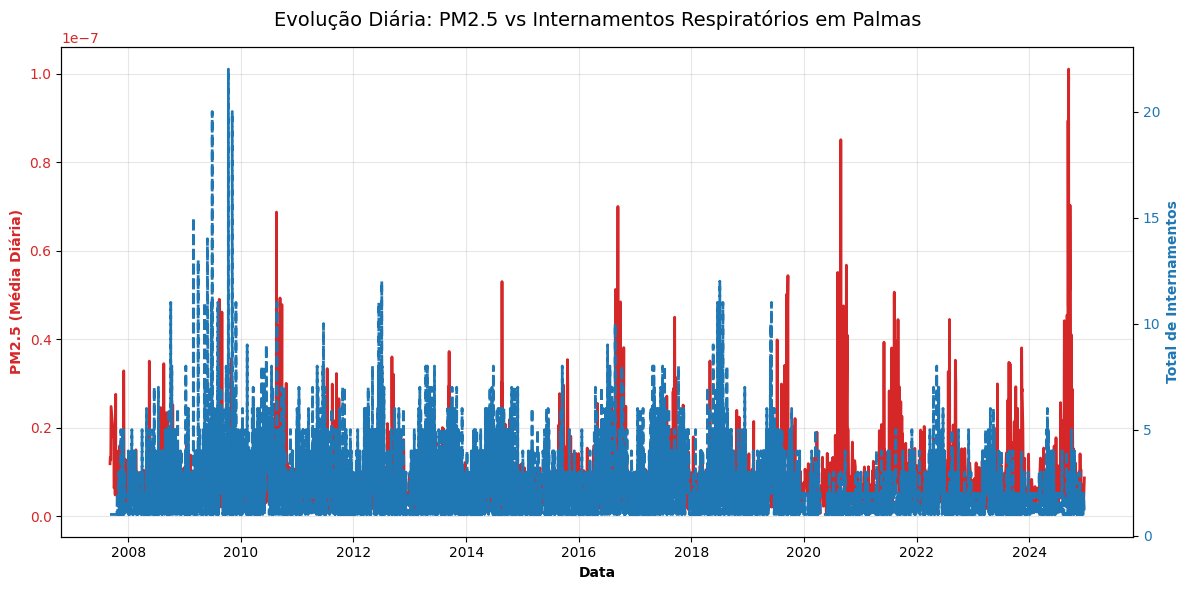

In [12]:
df_total_internamentos = df_final[['total_internamentos', 'DT_INTER']]

fig, ax1 = plt.subplots(figsize=(12, 6))

cor_pm = 'tab:red'
ax1.set_xlabel('Data', fontweight='bold')
ax1.set_ylabel('PM2.5 (Média Diária)', color=cor_pm, fontweight='bold')
ax1.plot(df_final['DT_INTER'], df_final['pm2p5'], color=cor_pm, linewidth=2, label='Poluição (PM2.5)')
ax1.tick_params(axis='y', labelcolor=cor_pm)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

cor_int = 'tab:blue'
ax2.set_ylabel('Total de Internamentos', color=cor_int, fontweight='bold')
ax2.plot(df_final['DT_INTER'], df_final['total_internamentos'], color=cor_int, linewidth=2, linestyle='--', label='Internamentos')
ax2.tick_params(axis='y', labelcolor=cor_int)

plt.title('Evolução Diária: PM2.5 vs Internamentos Respiratórios em Palmas', fontsize=14, pad=15)
fig.tight_layout()

plt.show()

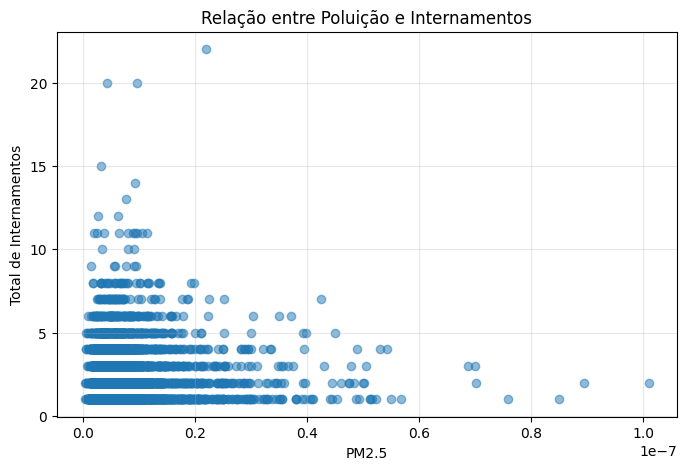

                        pm2p5  total_internamentos
pm2p5                1.000000            -0.021634
total_internamentos -0.021634             1.000000


In [15]:
import matplotlib.pyplot as plt

# Reaproveita o DataFrame agregado criado na primeira célula.
plt.figure(figsize=(8, 5))
plt.scatter(df_final['pm2p5'], df_final['total_internamentos'], alpha=0.5)
plt.xlabel("PM2.5")
plt.ylabel("Total de Internamentos")
plt.title("Relação entre Poluição e Internamentos")
plt.grid(True, alpha=0.3)
plt.show()

print(df_final[['pm2p5', 'total_internamentos']].corr())


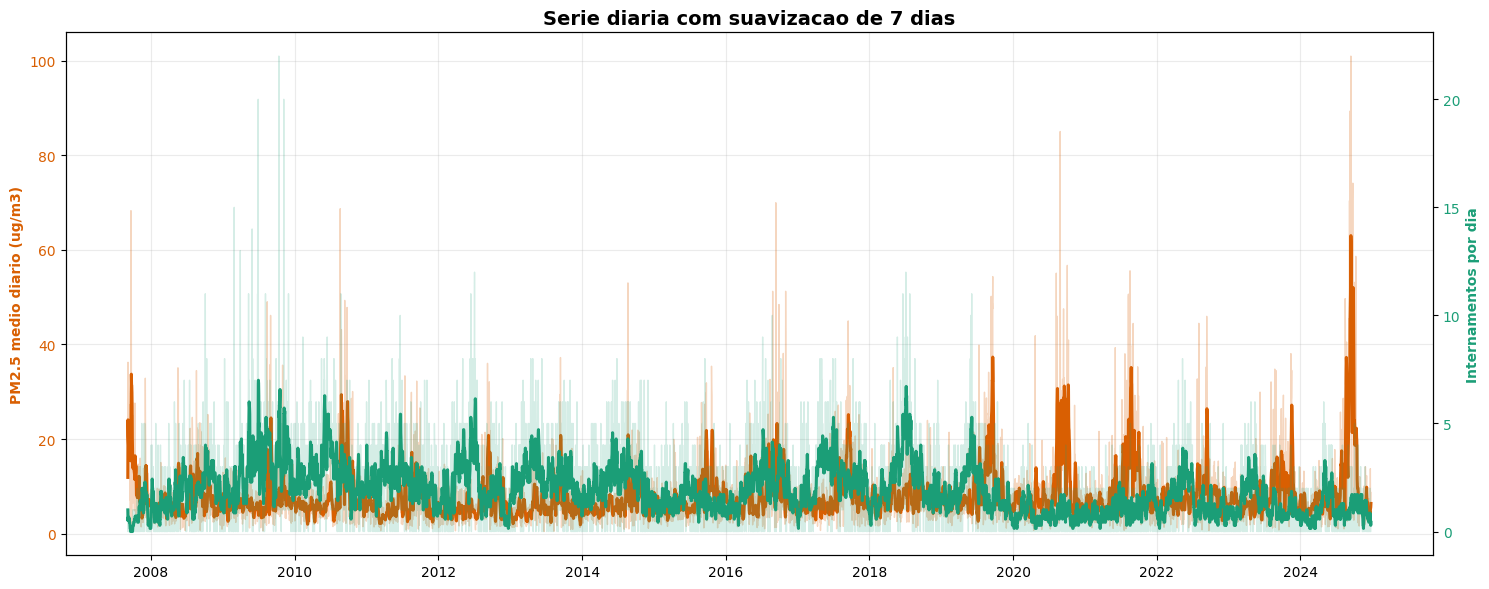

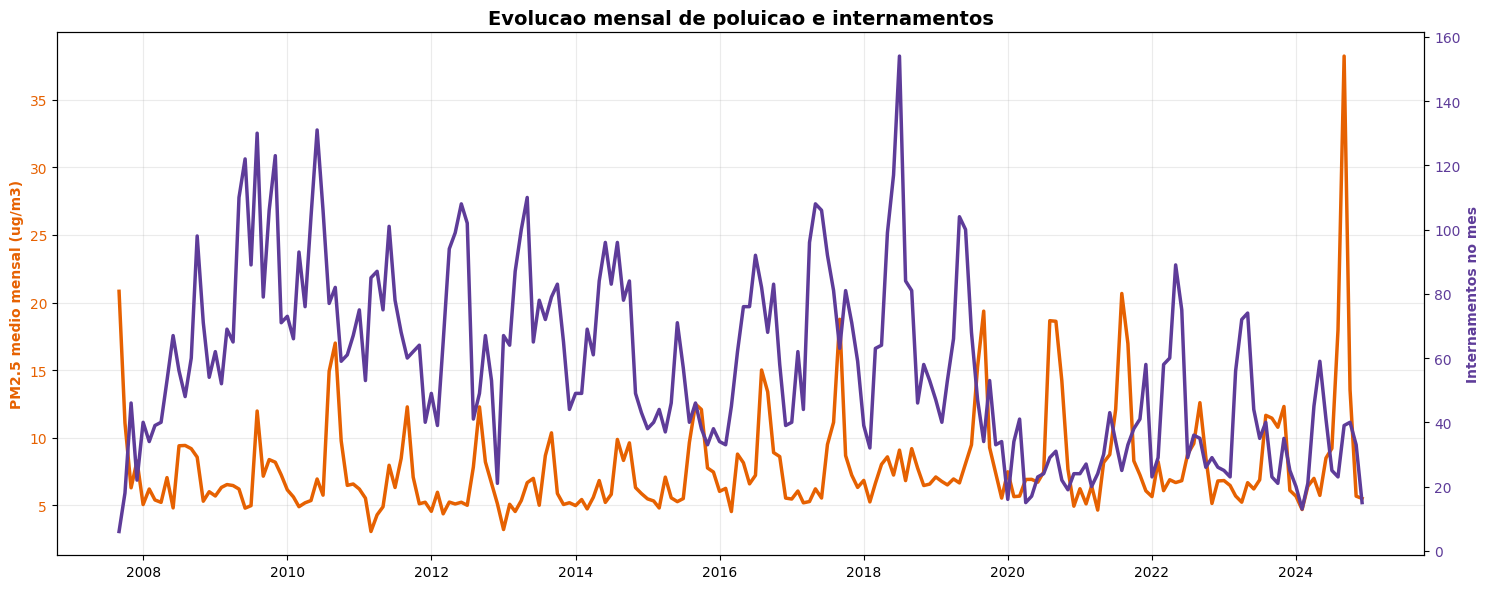

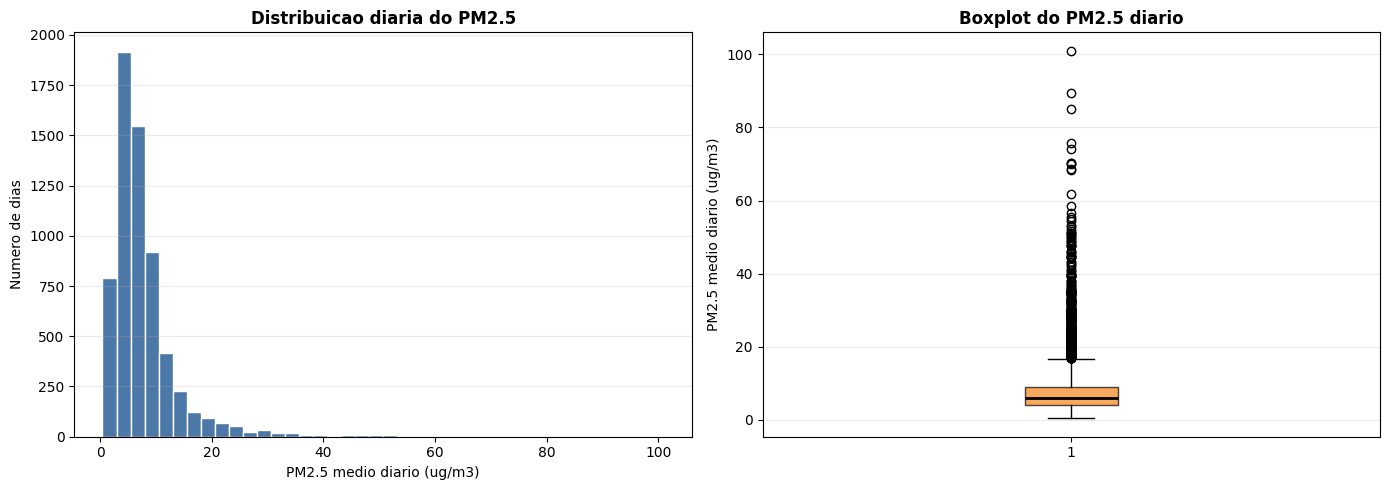

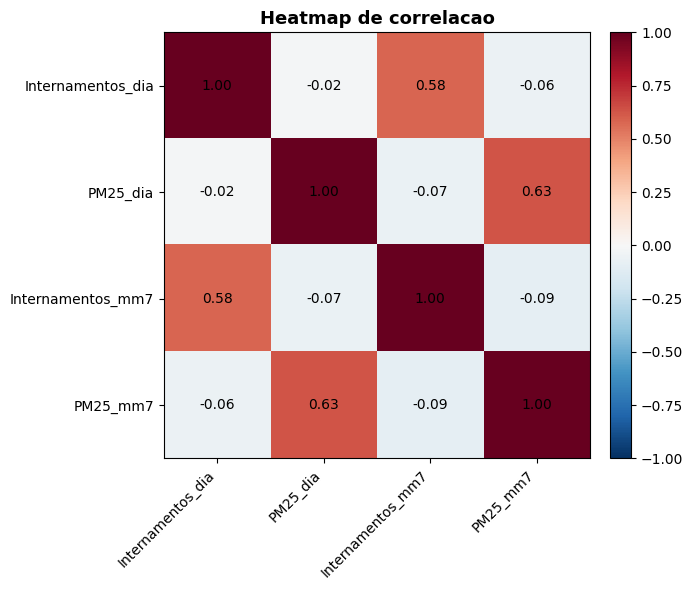

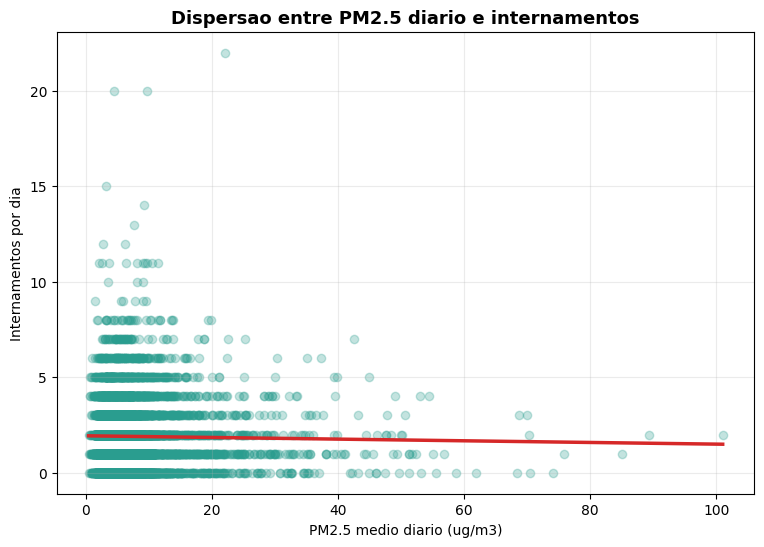

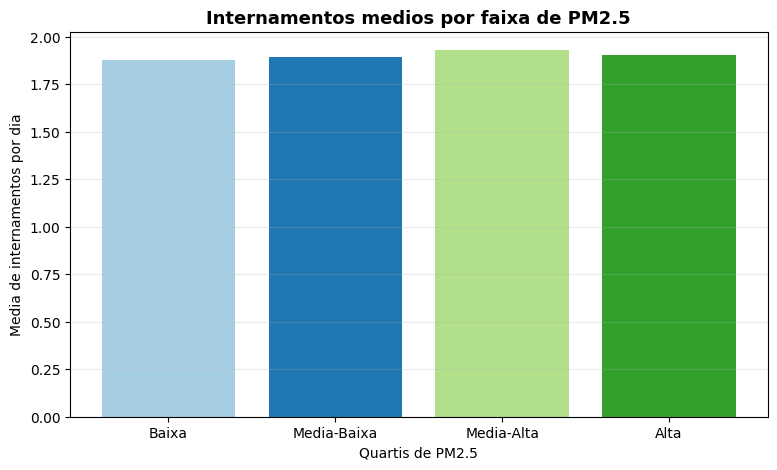

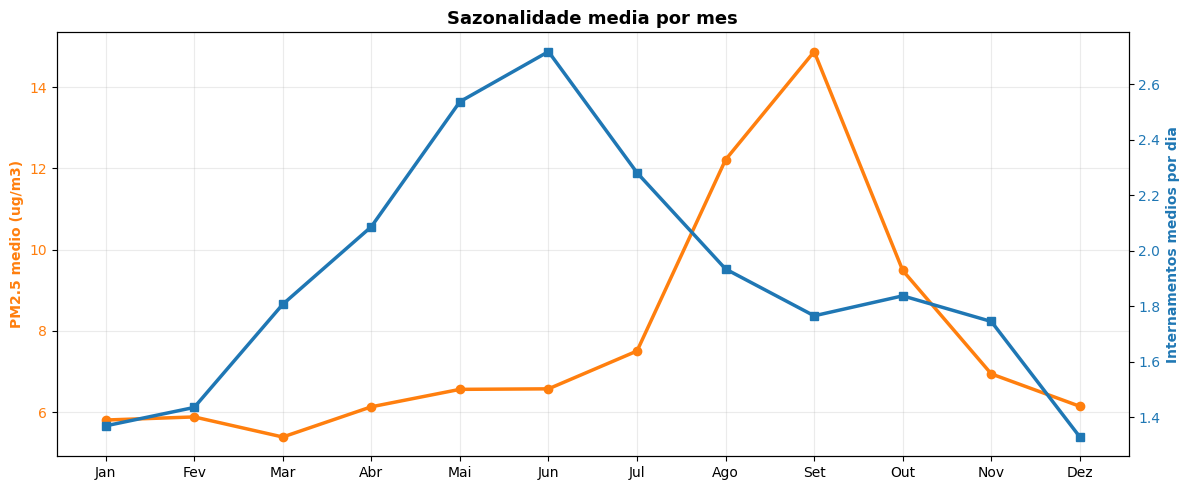

Correlacao diaria de Pearson:
                   internamentos_dia  pm25_medio_dia
internamentos_dia           1.000000       -0.017038
pm25_medio_dia             -0.017038        1.000000

Correlacao diaria de Spearman:
                   internamentos_dia  pm25_medio_dia
internamentos_dia           1.000000       -0.002584
pm25_medio_dia             -0.002584        1.000000

Correlacao mensal de Pearson:
                   internamentos_mes  pm25_medio_mes
internamentos_mes           1.000000       -0.157116
pm25_medio_mes             -0.157116        1.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Carga e preparação
df_clinico = pd.read_csv("csv/internamentos_respiratorios_palmas.csv")
df_climatico = pd.read_csv("csv/particulas_ar_palmas.csv")

df_clinico["DT_INTER"] = pd.to_datetime(df_clinico["DT_INTER"])
df_climatico["time"] = pd.to_datetime(df_climatico["time"])

# O PM2.5 está em notação muito pequena; para leitura acadêmica faz mais sentido
# exibir em ug/m3. A conversão abaixo é uma inferência baseada na escala do dado.
df_climatico["pm25_ug_m3"] = df_climatico["pm2p5"] * 1e9
df_climatico["data"] = df_climatico["time"].dt.normalize()

df_climatico_diario = (
    df_climatico.groupby("data", as_index=False)["pm25_ug_m3"]
    .mean()
    .rename(columns={"pm25_ug_m3": "pm25_medio_dia"})
)

df_clinico_diario = (
    df_clinico.groupby("DT_INTER")
    .size()
    .reset_index(name="internamentos_dia")
    .rename(columns={"DT_INTER": "data"})
)

# Mantem o calendario completo para nao perder dias sem internacao.
df_calendario = pd.DataFrame(
    {"data": pd.date_range(df_clinico["DT_INTER"].min(), df_clinico["DT_INTER"].max(), freq="D")}
)

df_analise = df_calendario.merge(df_clinico_diario, on="data", how="left")
df_analise["internamentos_dia"] = df_analise["internamentos_dia"].fillna(0).astype(int)
df_analise = df_analise.merge(df_climatico_diario, on="data", how="left")

df_analise["pm25_mm7"] = df_analise["pm25_medio_dia"].rolling(7, min_periods=1).mean()
df_analise["intern_mm7"] = df_analise["internamentos_dia"].rolling(7, min_periods=1).mean()
df_analise["ano"] = df_analise["data"].dt.year
df_analise["mes"] = df_analise["data"].dt.month
df_analise["ano_mes"] = df_analise["data"].dt.to_period("M").dt.to_timestamp()

df_mensal = (
    df_analise.groupby("ano_mes", as_index=False)
    .agg(
        internamentos_mes=("internamentos_dia", "sum"),
        pm25_medio_mes=("pm25_medio_dia", "mean"),
    )
)

df_sazonal = (
    df_analise.groupby("mes", as_index=False)
    .agg(
        pm25_medio=("pm25_medio_dia", "mean"),
        internamentos_medios=("internamentos_dia", "mean"),
    )
)

df_analise["faixa_pm25"] = pd.qcut(
    df_analise["pm25_medio_dia"],
    q=4,
    labels=["Baixa", "Media-Baixa", "Media-Alta", "Alta"],
)

df_quartis = (
    df_analise.groupby("faixa_pm25", observed=False, as_index=False)
    .agg(
        pm25_medio=("pm25_medio_dia", "mean"),
        internamentos_medios=("internamentos_dia", "mean"),
        internamentos_mediana=("internamentos_dia", "median"),
    )
)

corr_pearson = df_analise[["internamentos_dia", "pm25_medio_dia"]].corr(method="pearson")
corr_spearman = df_analise[["internamentos_dia", "pm25_medio_dia"]].corr(method="spearman")
corr_mensal = df_mensal[["internamentos_mes", "pm25_medio_mes"]].corr(method="pearson")



# 2. Grafico: serie diaria com media movel
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_analise["data"], df_analise["pm25_medio_dia"], color="#d95f02", alpha=0.25, linewidth=1)
ax1.plot(df_analise["data"], df_analise["pm25_mm7"], color="#d95f02", linewidth=2.2, label="PM2.5 - media movel 7d")
ax1.set_ylabel("PM2.5 medio diario (ug/m3)", color="#d95f02", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#d95f02")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(df_analise["data"], df_analise["internamentos_dia"], color="#1b9e77", alpha=0.18, linewidth=1)
ax2.plot(df_analise["data"], df_analise["intern_mm7"], color="#1b9e77", linewidth=2.2, label="Internacoes - media movel 7d")
ax2.set_ylabel("Internamentos por dia", color="#1b9e77", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#1b9e77")

plt.title("Serie diaria com suavizacao de 7 dias", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()



# 3. Grafico: agregacao mensal
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_mensal["ano_mes"], df_mensal["pm25_medio_mes"], color="#e66101", linewidth=2.5)
ax1.set_ylabel("PM2.5 medio mensal (ug/m3)", color="#e66101", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#e66101")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(df_mensal["ano_mes"], df_mensal["internamentos_mes"], color="#5e3c99", linewidth=2.5)
ax2.set_ylabel("Internamentos no mes", color="#5e3c99", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#5e3c99")

plt.title("Evolucao mensal de poluicao e internamentos", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()



# 4. Distribuicao do PM2.5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_analise["pm25_medio_dia"].dropna(), bins=40, color="#4c78a8", edgecolor="white")
axes[0].set_title("Distribuicao diaria do PM2.5", fontweight="bold")
axes[0].set_xlabel("PM2.5 medio diario (ug/m3)")
axes[0].set_ylabel("Numero de dias")
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].boxplot(
    df_analise["pm25_medio_dia"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#f58518", alpha=0.7),
    medianprops=dict(color="black", linewidth=2),
)
axes[1].set_title("Boxplot do PM2.5 diario", fontweight="bold")
axes[1].set_ylabel("PM2.5 medio diario (ug/m3)")
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# 5. Heatmap de correlacao
correlation_matrix = pd.DataFrame(
    {
        "Internamentos_dia": df_analise["internamentos_dia"],
        "PM25_dia": df_analise["pm25_medio_dia"],
        "Internamentos_mm7": df_analise["intern_mm7"],
        "PM25_mm7": df_analise["pm25_mm7"],
    }
).corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)

for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Heatmap de correlacao", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# 6. Dispersao com linha de tendencia
x = df_analise["pm25_medio_dia"].to_numpy()
y = df_analise["internamentos_dia"].to_numpy()
coef = np.polyfit(x, y, 1)
polinomio = np.poly1d(coef)
x_linha = np.linspace(np.nanmin(x), np.nanmax(x), 200)

plt.figure(figsize=(9, 6))
plt.scatter(df_analise["pm25_medio_dia"], df_analise["internamentos_dia"], alpha=0.28, color="#2a9d8f")
plt.plot(x_linha, polinomio(x_linha), color="#d62828", linewidth=2.5)
plt.title("Dispersao entre PM2.5 diario e internamentos", fontsize=13, fontweight="bold")
plt.xlabel("PM2.5 medio diario (ug/m3)")
plt.ylabel("Internamentos por dia")
plt.grid(True, alpha=0.25)
plt.show()


# 7. Comparacao por quartis de poluicao
plt.figure(figsize=(9, 5))
plt.bar(df_quartis["faixa_pm25"].astype(str), df_quartis["internamentos_medios"], color=["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c"])
plt.title("Internamentos medios por faixa de PM2.5", fontsize=13, fontweight="bold")
plt.xlabel("Quartis de PM2.5")
plt.ylabel("Media de internamentos por dia")
plt.grid(True, axis="y", alpha=0.25)
plt.show()


# 8. Sazonalidade por mes
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_sazonal["mes"], df_sazonal["pm25_medio"], marker="o", color="#ff7f0e", linewidth=2.5)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(meses)
ax1.set_ylabel("PM2.5 medio (ug/m3)", color="#ff7f0e", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#ff7f0e")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(df_sazonal["mes"], df_sazonal["internamentos_medios"], marker="s", color="#1f77b4", linewidth=2.5)
ax2.set_ylabel("Internamentos medios por dia", color="#1f77b4", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

plt.title("Sazonalidade media por mes", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


print("Correlacao diaria de Pearson:")
print(corr_pearson)
print("\nCorrelacao diaria de Spearman:")
print(corr_spearman)
print("\nCorrelacao mensal de Pearson:")
print(corr_mensal)
